In [22]:
# =========================
# Cell 1: Imports + config
# =========================
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Point this to your eval_results directory
directory_path = "runs/qwen35_9b_both_aug/eval_results/"

json_files = [
    f for f in glob.glob(os.path.join(directory_path, "*.json"))
    if os.path.basename(f) != "all_metrics.json"
]

print(f"Found {len(json_files)} result files")
for f in sorted(json_files)[:5]:
    print(" -", os.path.basename(f))

Found 15 result files
 - base_pretrained.json
 - checkpoint-1308.json
 - checkpoint-1744.json
 - checkpoint-2180.json
 - checkpoint-2616.json


In [23]:
# ==========================================
# Cell 2: Helpers to read the new file shape
# ==========================================
ALL_FIELDS = ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"]
FIELDS_BY_SUBSET = {
    "combined": ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"],
    "forklift": ["hazard_label", "hazard_present", "zone_relation", "object_state", "object_direction"],
    "robot": ["hazard_label", "hazard_present", "zone_relation", "object_state"],
}

def parse_step(filename: str) -> int:
    name = filename.lower()
    if "base" in name:
        return 0
    if "final" in name:
        return 999999

    m = re.search(r"checkpoint[-_]?(\d+)", name)
    if m:
        return int(m.group(1))

    m = re.search(r"[-_](\d+)\.json$", name)
    if m:
        return int(m.group(1))

    return -1

def safe_get(d, *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(k)
        if cur is None:
            return default
    return cur

def get_field_f1(subset_metrics, field):
    return safe_get(subset_metrics, "per_field_metrics", field, "macro_f1", default=np.nan)

def get_field_fp(subset_metrics, field):
    labels = safe_get(subset_metrics, "per_field_metrics", field, "labels", default={}) or {}
    return sum((info or {}).get("fp", 0) for info in labels.values())

def build_summary_row(file_path, content):
    filename = os.path.basename(file_path)
    metrics = content.get("metrics", {})
    row = {
        "checkpoint": filename.replace(".json", ""),
        "filename": filename,
        "step": parse_step(filename),
        "adapter_name": metrics.get("adapter_name"),
        "inference_time_sec": metrics.get("inference_time_sec", np.nan),
        "samples_per_sec": metrics.get("samples_per_sec", np.nan),
    }

    for subset in ["combined", "forklift", "robot"]:
        subset_metrics = safe_get(metrics, subset, default=None)
        if subset_metrics is None:
            subset_metrics = safe_get(metrics, "by_task", subset, default={}) or {}

        row[f"{subset}_total_samples"] = subset_metrics.get("total_samples", np.nan)
        row[f"{subset}_exact_match_accuracy"] = subset_metrics.get("exact_match_accuracy", np.nan)
        row[f"{subset}_relevant_field_accuracy"] = subset_metrics.get("relevant_field_accuracy", np.nan)
        row[f"{subset}_parse_failures"] = subset_metrics.get("parse_failures", np.nan)
        row[f"{subset}_gt_parse_failures"] = subset_metrics.get("ground_truth_parse_failures", np.nan)
        row[f"{subset}_hazard_f1"] = safe_get(subset_metrics, "hazard_present_binary", "f1", default=np.nan)
        row[f"{subset}_hazard_recall"] = safe_get(subset_metrics, "hazard_present_binary", "recall", default=np.nan)
        row[f"{subset}_hazard_precision"] = safe_get(subset_metrics, "hazard_present_binary", "precision", default=np.nan)

        for field in ALL_FIELDS:
            row[f"{subset}_{field}_acc"] = safe_get(subset_metrics, "per_field_accuracy", field, default=np.nan)
            row[f"{subset}_{field}_f1"] = get_field_f1(subset_metrics, field)
            row[f"{subset}_{field}_fp"] = get_field_fp(subset_metrics, field)

    return row

summary_rows = []

for file_path in json_files:
    with open(file_path, "r", encoding="utf-8") as f:
        content = json.load(f)
    summary_rows.append(build_summary_row(file_path, content))

summary_df = pd.DataFrame(summary_rows).sort_values(["step", "checkpoint"]).reset_index(drop=True)
summary_df.head()

,checkpoint,filename,step,adapter_name,inference_time_sec,samples_per_sec,combined_total_samples,combined_exact_match_accuracy,combined_relevant_field_accuracy,combined_parse_failures,...,robot_hazard_present_fp,robot_zone_relation_acc,robot_zone_relation_f1,robot_zone_relation_fp,robot_object_state_acc,robot_object_state_f1,robot_object_state_fp,robot_object_direction_acc,robot_object_direction_f1,robot_object_direction_fp
0,base_pretrained,base_pretrained.json,0,base_pretrained,4367.16,0.1743,761,0.1235,0.3209,0,...,537,0.0196,0.0136,550,0.4991,0.3594,281,NaN,NaN,0
1,checkpoint-436,checkpoint-436.json,436,checkpoint-436,3781.23,0.2013,761,0.8739,0.9202,0,...,24,0.9804,0.4950,11,0.9750,0.4937,14,NaN,NaN,0
2,checkpoint-872,checkpoint-872.json,872,checkpoint-872,3798.84,0.2003,761,0.9198,0.9414,0,...,18,0.9804,0.4950,11,0.9857,0.7964,8,NaN,NaN,0
3,checkpoint-1308,checkpoint-1308.json,1308,checkpoint-1308,2270.91,0.3351,761,0.5427,0.5687,299,...,229,0.6007,0.2519,224,0.5989,0.3682,225,NaN,NaN,0
4,checkpoint-1744,checkpoint-1744.json,1744,checkpoint-1744,3.80,200.1839,761,0.0000,0.0000,761,...,561,0.0000,0.0000,561,0.0000,0.0000,561,NaN,NaN,0


In [24]:
# ==================================
# Cell 3: Quick summary table to use
# ==================================
core_cols = [
    "checkpoint", "step",
    "combined_exact_match_accuracy", "combined_relevant_field_accuracy", "combined_hazard_f1",
    "forklift_exact_match_accuracy", "forklift_relevant_field_accuracy", "forklift_hazard_f1",
    "robot_exact_match_accuracy", "robot_relevant_field_accuracy", "robot_hazard_f1",
    "samples_per_sec"
]

display(summary_df[core_cols].round(4))

,checkpoint,step,combined_exact_match_accuracy,combined_relevant_field_accuracy,combined_hazard_f1,forklift_exact_match_accuracy,forklift_relevant_field_accuracy,forklift_hazard_f1,robot_exact_match_accuracy,robot_relevant_field_accuracy,robot_hazard_f1,samples_per_sec
0,base_pretrained,0,0.1235,0.3209,0.0000,0.450,0.702,0.0000,0.0071,0.1511,0.0000,0.1743
1,checkpoint-436,436,0.8739,0.9202,0.9547,0.640,0.814,0.0000,0.9572,0.9675,0.9781,0.2013
2,checkpoint-872,872,0.9198,0.9414,0.9644,0.785,0.865,0.3125,0.9679,0.9755,0.9835,0.2003
3,checkpoint-1308,1308,0.5427,0.5687,0.7467,0.405,0.508,0.6500,0.5918,0.5958,0.7511,0.3351
4,checkpoint-1744,1744,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,200.1839
5,checkpoint-2180,2180,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,216.6346
6,checkpoint-2616,2616,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,213.8406
7,checkpoint-3052,3052,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,203.2368
8,checkpoint-3488,3488,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,205.6257
9,checkpoint-3924,3924,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,215.1716


In [25]:
from adjustText import adjust_text

# =======================================================
# Plot helpers with automatic label de-overlap
# =======================================================
def annotate_series(x_vals, y_vals, texts, fmt="{:.2f}", fontsize=8):
    for x, y in zip(x_vals, y_vals):
        if pd.isna(y):
            continue
        txt = plt.text(
            x, y, fmt.format(y),
            fontsize=fontsize,
            ha="center",
            va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.2)
        )
        texts.append(txt)


def plot_metric_family(df, subset, metric_suffix, title=None, figsize=(14, 5)):
    valid_fields = []
    for field in FIELDS_BY_SUBSET[subset]:
        col = f"{subset}_{field}_{metric_suffix}"
        if col in df.columns and df[col].notna().any():
            valid_fields.append((field, col))

    if not valid_fields:
        print(f"No data to plot for {subset} / {metric_suffix}")
        return

    plt.figure(figsize=figsize)
    texts = []

    for field, col in valid_fields:
        label = field.replace("_", " ").title()
        plt.plot(df["checkpoint"], df[col], marker="o", linewidth=1.8, label=label)

        fmt = "{:.0f}" if metric_suffix == "fp" else "{:.2f}"
        annotate_series(df["checkpoint"], df[col], texts, fmt=fmt)

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        only_move={"points": "y", "text": "y"},
        force_text=0.8,
        force_points=0.3
    )

    if title is None:
        title = f"{subset.title()} - {metric_suffix.upper()}"

    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("Checkpoint")
    plt.ylabel(metric_suffix.upper())
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_overall_metrics(df, subset, figsize=(14, 5)):
    cols = [
        f"{subset}_exact_match_accuracy",
        f"{subset}_relevant_field_accuracy",
        f"{subset}_hazard_f1",
    ]
    labels = ["Exact Match", "Relevant Field Acc", "Hazard F1"]

    plt.figure(figsize=figsize)
    texts = []

    for col, label in zip(cols, labels):
        if col in df.columns and df[col].notna().any():
            plt.plot(df["checkpoint"], df[col], marker="o", linewidth=2, label=label)
            annotate_series(df["checkpoint"], df[col], texts, fmt="{:.2f}")

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        only_move={"points": "y", "text": "y"},
        force_text=0.8,
        force_points=0.3
    )

    plt.title(f"{subset.title()} - Overall Scores", fontsize=13, fontweight="bold")
    plt.xlabel("Checkpoint")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

0 [0.70373799 0.5455318 ]
15 [0.42680163 0.64305062]
1 [0.5945173  0.79656553]
16 [0.07389026 0.62104159]
46 [-0.83753712  0.21380667]
2 [0.13659749 0.3192995 ]
17 [ 0.79528888 -0.22836778]
3 [-0.53977412 -0.94821901]
18 [ 0.67479915 -0.54363016]
4 [-0.53331348  0.12231769]
19 [-0.18399174  0.30846572]
34 [-0.44677348 -0.53211015]
49 [-0.66554442 -0.47046284]
64 [-0.30432616 -0.12093941]
5 [-0.60784678  0.93262592]
20 [-0.56762842 -0.52608078]
35 [0.40262108 0.74208203]
50 [-0.09068452  0.42622978]
65 [ 0.78849487 -0.8468757 ]
6 [-0.23838654 -0.5968288 ]
21 [-0.09733151 -0.23806916]
36 [ 0.3772751  -0.69827985]
51 [-0.60620073 -0.69124771]
66 [0.84426784 0.13758094]
7 [-0.96172656 -0.99420565]
22 [-0.24134532  0.40346295]
37 [-0.8028235 -0.8026336]
52 [0.51919588 0.52923042]
67 [0.04499976 0.51619707]
8 [-0.04176826 -0.44476467]
23 [ 0.0414575  -0.23805715]
38 [ 0.5271615  -0.33627394]
53 [0.08373092 0.98460206]
68 [0.49110092 0.62732032]
9 [ 0.4080105  -0.11530088]
24 [0.39308253 0.98

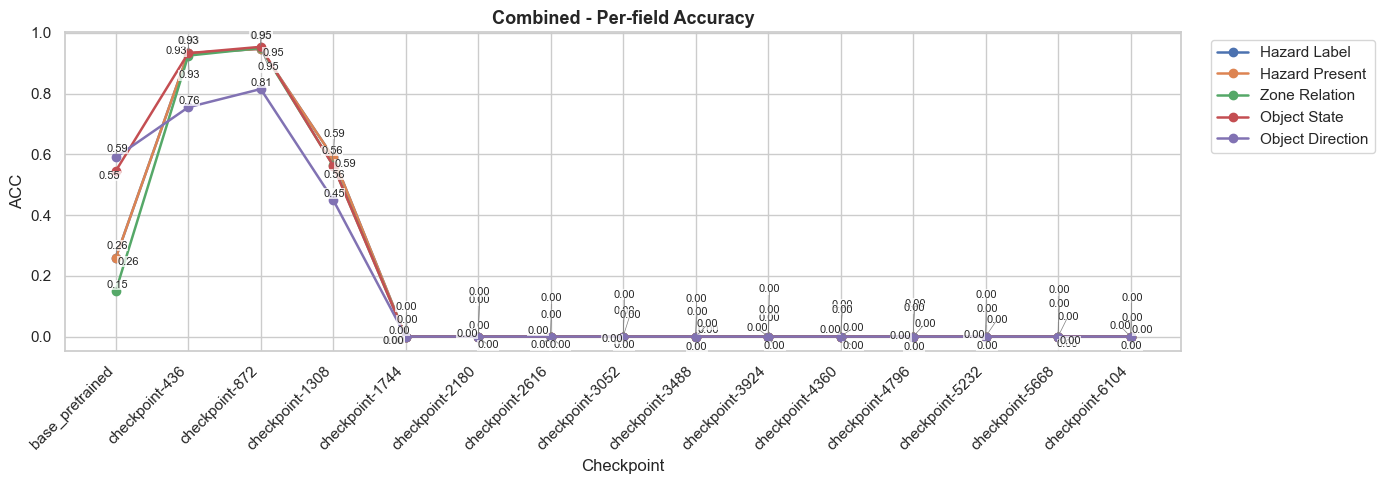

4 [-0.68594081 -0.27712957]
19 [0.95178407 0.38275504]
34 [-0.905026    0.35684024]
49 [0.37593809 0.00804273]
64 [0.78137183 0.75826263]
5 [0.82293757 0.14534215]
20 [-0.37752687  0.821841  ]
35 [0.21791247 0.21035335]
50 [0.40548974 0.78536522]
65 [-0.23600308  0.85428185]
6 [-0.61724829  0.28667108]
21 [ 0.76404343 -0.20452901]
36 [0.66731739 0.69990334]
51 [-0.95294625  0.3714499 ]
66 [-0.32701006  0.7093875 ]
7 [-0.0557243 -0.6412793]
22 [ 0.3051257  -0.24141646]
37 [-0.19150491 -0.12529097]
52 [ 0.56912547 -0.99794527]
67 [-0.35457623 -0.67569977]
8 [0.47808196 0.93679875]
23 [-0.83791455  0.15286647]
38 [ 0.955128   -0.20785257]
53 [-0.85594227  0.12246428]
68 [-0.47679576  0.84836405]
9 [ 0.30423978 -0.05409913]
24 [-0.63400262  0.58149068]
39 [0.59932822 0.1939123 ]
54 [ 0.54132891 -0.92543903]
69 [0.12875707 0.19932753]
10 [ 0.02694789 -0.34044288]
25 [-0.01876681  0.5639362 ]
40 [ 0.4295603  -0.32498341]
55 [0.5190476  0.19617507]
70 [ 0.36763375 -0.09335847]
11 [-0.86070604

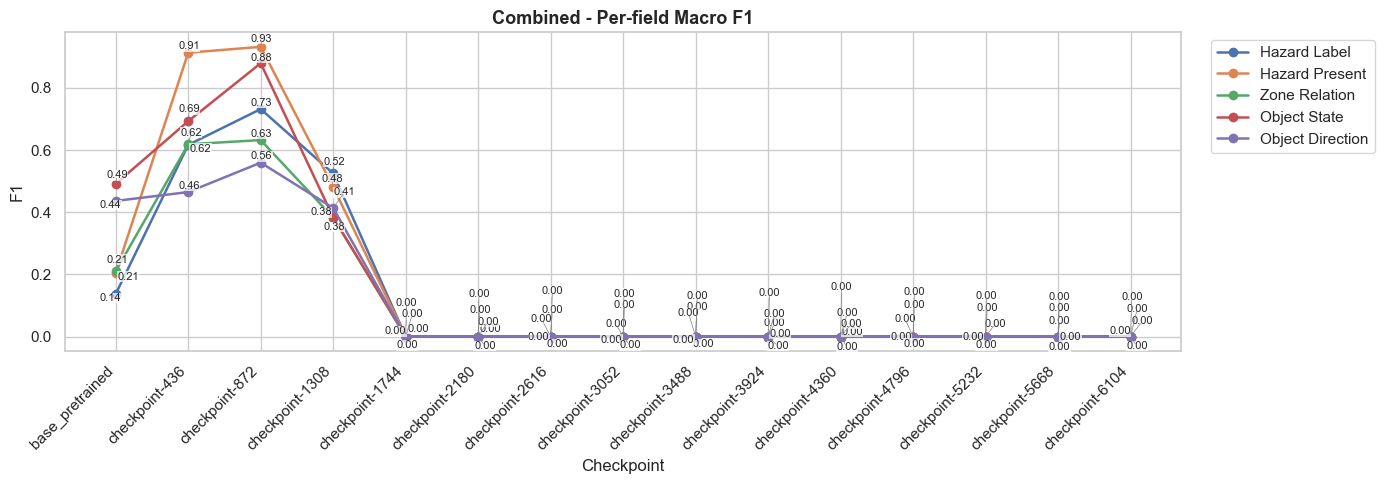

0 [0.2234337  0.17510169]
15 [-0.94908517  0.10209665]
1 [-0.8827057  -0.88796117]
16 [-0.1204013   0.48199737]
46 [0.47100649 0.06315901]
2 [-0.28696231  0.1713561 ]
17 [-0.09800329  0.46673474]
3 [0.62438558 0.22039903]
18 [-0.57077078  0.50683276]
4 [ 0.26837467 -0.70152525]
19 [ 0.61856687 -0.2972373 ]
34 [-0.54753752  0.93234515]
49 [ 0.66915095 -0.9946827 ]
5 [-0.57533185 -0.95660881]
20 [0.10851722 0.85378717]
35 [0.09952273 0.68408911]
50 [0.62619109 0.10088508]
6 [-0.04500668  0.34346584]
21 [ 0.65870649 -0.25731429]
36 [ 0.70702454 -0.77277199]
51 [ 0.41348603 -0.46466891]
7 [0.00970749 0.21638243]
22 [-0.6324583  -0.83113221]
37 [0.46421175 0.31540747]
52 [0.92261051 0.27428305]
8 [0.39222635 0.31874015]
23 [-0.21312481  0.04454717]
38 [-0.56458449 -0.69827634]
53 [0.73279671 0.60270034]
9 [0.19783516 0.27119059]
24 [-0.32762831 -0.20822723]
39 [0.45005071 0.30396025]
54 [-0.15660249  0.43563393]
10 [0.46536388 0.4660569 ]
25 [ 0.75337932 -0.55573917]
40 [ 0.60562634 -0.9291

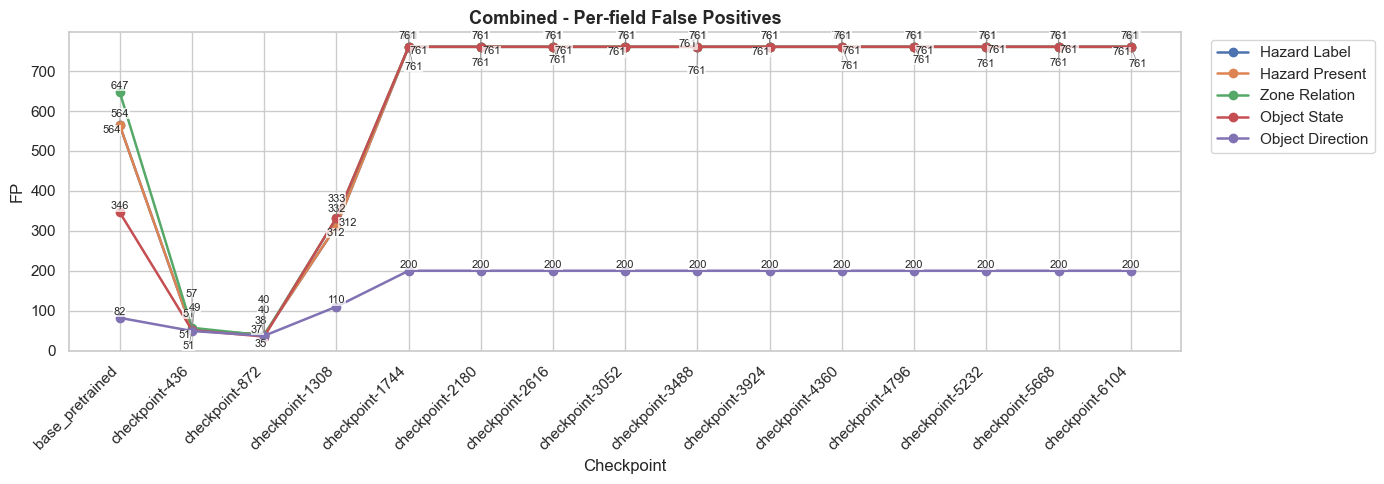

0 [0.19635866 0.38908359]
15 [-0.73780533  0.54767337]
1 [ 0.65153073 -0.09591365]
16 [0.07775325 0.94364228]
32 [-0.43157669  0.44890818]
47 [-0.43206836 -0.64388154]
2 [-0.80151404  0.91121348]
17 [-0.08446466  0.14850297]
33 [-0.13513258  0.91636705]
48 [0.87536688 0.83432929]
3 [ 0.6640681  -0.47758346]
18 [0.85767589 0.64238571]
4 [0.93622927 0.85773206]
19 [-0.17973714  0.82522057]
34 [ 0.49029274 -0.94262468]
49 [0.11460815 0.81358378]
64 [-0.4897733  -0.08840229]
5 [ 0.22900923 -0.88729399]
20 [ 0.46834324 -0.45690862]
35 [-0.56557456 -0.12262929]
50 [-0.88349079 -0.80574284]
65 [-0.1613902  -0.44772184]
6 [-0.89335732 -0.54283357]
21 [ 0.85938164 -0.91948697]
36 [-0.946394    0.58789973]
51 [-0.24657782  0.70890673]
66 [0.32183002 0.71556857]
7 [0.86379763 0.24058443]
22 [-0.68318866  0.88458803]
37 [0.84034073 0.23883841]
52 [-0.91810018  0.62993687]
67 [-0.54086171 -0.55382195]
8 [ 0.54801541 -0.67108749]
23 [-0.77665603 -0.38145505]
38 [-0.27072262  0.75877877]
53 [ 0.45110

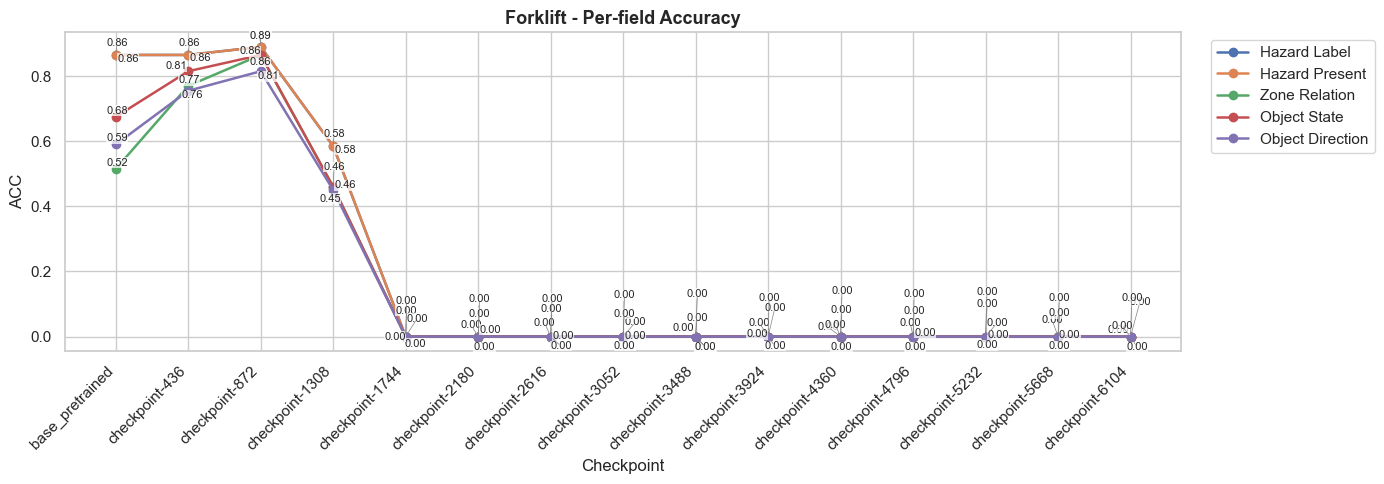

0 [-0.51920243 -0.64981739]
15 [ 0.28791793 -0.42622285]
1 [ 0.86000584 -0.36134899]
16 [ 0.0758731  -0.74303462]
2 [-0.9753497  -0.73672823]
17 [-0.80045529 -0.49481849]
3 [-0.72647632  0.51318327]
18 [-0.016158    0.21253625]
4 [-0.63389658  0.57210797]
19 [ 0.55288709 -0.07902399]
34 [ 0.12292095 -0.7057489 ]
49 [0.62057923 0.73112899]
64 [-0.23847127  0.69057338]
5 [-0.69142044  0.52331049]
20 [ 0.29792078 -0.38351636]
35 [-0.09538577 -0.40177415]
50 [0.25901033 0.54568698]
65 [-0.03861619 -0.21769739]
6 [ 0.03483478 -0.9766595 ]
21 [-0.1185604   0.89638877]
36 [-0.58674191 -0.88396422]
51 [-0.03966114  0.40983988]
66 [-0.19017314  0.43653655]
7 [-0.32130272  0.48037799]
22 [-0.91070984 -0.29774732]
37 [0.95015303 0.91124551]
52 [0.41643059 0.58069778]
67 [-0.21619556 -0.18824724]
8 [-0.20847901  0.5873288 ]
23 [-0.57130337 -0.84318041]
38 [0.57494419 0.98841694]
53 [ 0.72488433 -0.66154336]
68 [-0.41147666 -0.32143128]
9 [0.81460521 0.73822409]
24 [0.51694995 0.78814443]
39 [-0.48

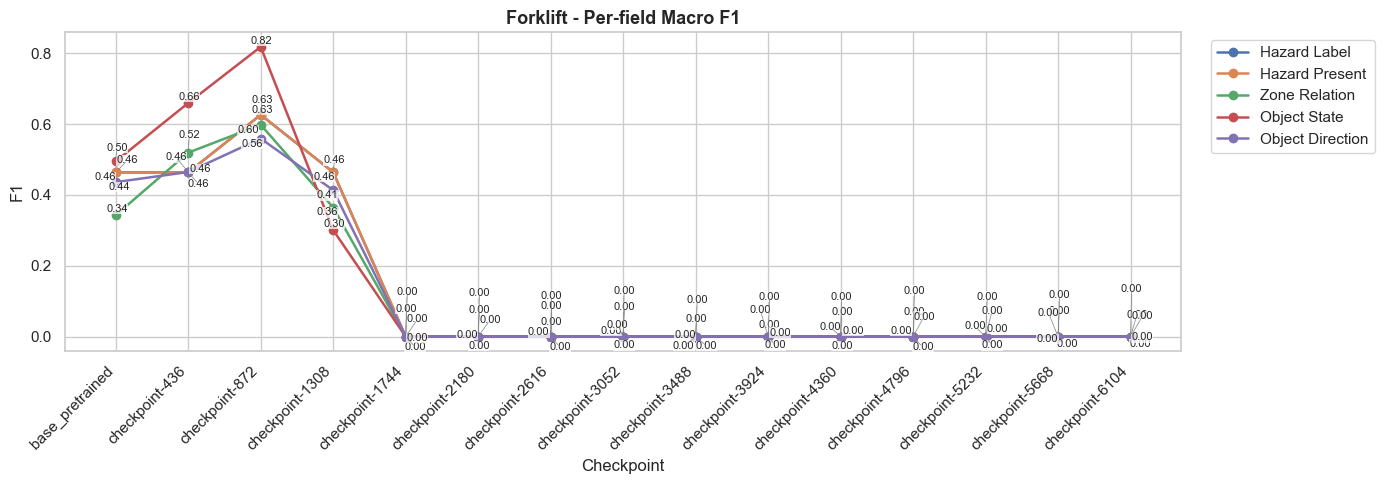

0 [0.96199537 0.79898041]
15 [-0.70627907 -0.66411927]
1 [-0.352964  -0.0724731]
16 [-0.15973761 -0.30831051]
2 [ 0.24549056 -0.55460335]
17 [0.48752027 0.83421484]
32 [ 0.09288234 -0.18809102]
47 [-0.12480613 -0.53805315]
3 [-0.98866087 -0.55517102]
18 [-0.68186012 -0.28619967]
33 [0.03607742 0.19041408]
48 [-0.99036151  0.74136545]
4 [-0.5911163   0.92710216]
19 [-0.711395    0.92944366]
34 [-0.07547656 -0.86773196]
49 [0.26288815 0.14861003]
64 [-0.94338162  0.15313714]
5 [ 0.62113231 -0.84592304]
20 [-0.39174793 -0.12511613]
35 [0.27228023 0.24298941]
50 [-0.39426134  0.77665159]
65 [-0.77778646 -0.19431488]
6 [-0.46552542 -0.89417443]
21 [0.558929   0.44515539]
36 [ 0.66146224 -0.44229227]
51 [-0.00289217  0.03477852]
66 [ 0.17576311 -0.49865367]
7 [-0.28243349 -0.51559113]
22 [-0.93120774  0.59356343]
37 [-0.09642937  0.0124708 ]
52 [0.86618274 0.70778699]
67 [ 0.62011557 -0.92411693]
8 [-0.61839631 -0.22910062]
23 [ 0.50775576 -0.39752187]
38 [ 0.69480411 -0.85070323]
53 [-0.171

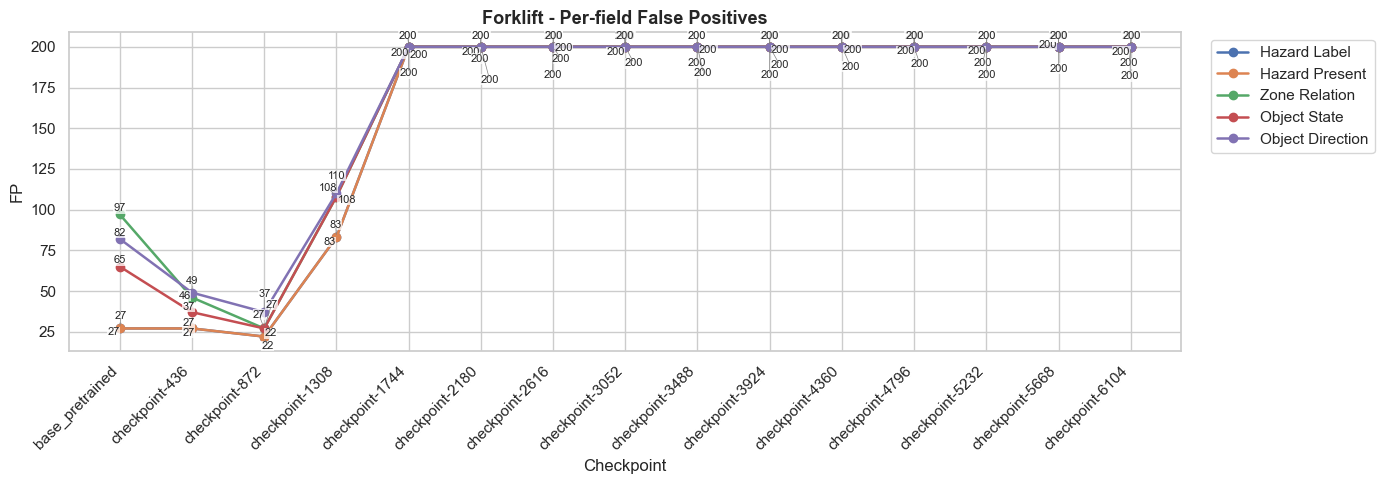

0 [-0.39419939 -0.35222904]
15 [ 0.01813258 -0.24549134]
1 [-0.01620964 -0.34947277]
16 [-0.71921108 -0.93451861]
2 [-0.34707995 -0.92284684]
17 [-0.02910972  0.31097924]
3 [0.31429647 0.65945889]
18 [-0.97326014  0.7559705 ]
4 [0.14577757 0.68601453]
19 [ 0.44770341 -0.00485823]
34 [ 0.34165648 -0.78554359]
49 [0.10768278 0.26784222]
5 [ 0.54157925 -0.27298416]
20 [ 0.85018516 -0.86209724]
35 [-0.01068473 -0.78360131]
50 [0.0833212  0.35884773]
6 [ 0.38593131 -0.71768581]
21 [0.11062627 0.87850746]
36 [0.97472417 0.29284586]
51 [ 0.28809248 -0.44957375]
7 [-0.50970948  0.55237637]
22 [-0.93445906 -0.76832662]
37 [-0.11487768 -0.73952579]
52 [-0.12351314 -0.68496555]
8 [ 0.45101475 -0.8635912 ]
23 [-0.74646427  0.46899623]
38 [-0.62271045  0.13758354]
53 [ 0.71950602 -0.94323402]
9 [-0.60833389 -0.56101318]
24 [ 0.54527705 -0.16554106]
39 [-0.98424148  0.72786735]
54 [-0.10063611 -0.98144079]
10 [-0.55155734  0.56783105]
25 [-0.53902697  0.60787057]
40 [-0.26639869  0.73594223]
55 [ 0.

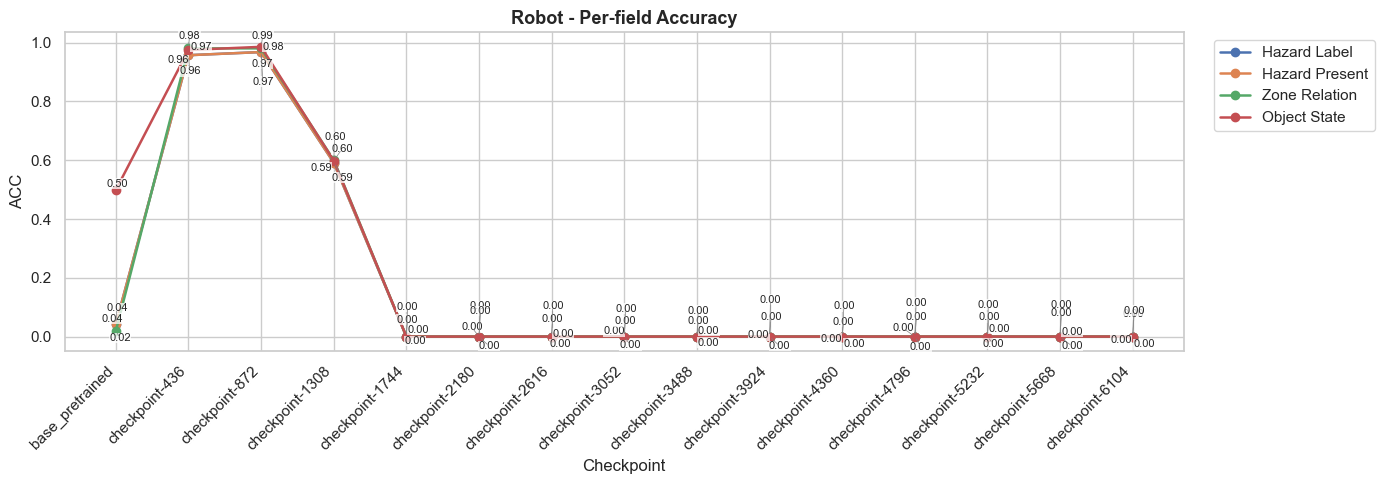

0 [0.9840424  0.81072183]
15 [-0.4392797  -0.40760481]
1 [-0.50514984 -0.70426736]
16 [-0.96422364 -0.59312959]
2 [0.90474852 0.955835  ]
17 [-0.80414035  0.44736183]
3 [ 0.94319419 -0.71861679]
18 [0.10349848 0.7657731 ]
4 [-0.20083173 -0.02991979]
19 [-0.50933874 -0.56772065]
34 [0.7102417  0.79643647]
49 [0.17826864 0.85250678]
5 [-0.14001276  0.3253333 ]
20 [-0.87101573 -0.29177083]
35 [0.61741499 0.53331717]
50 [-0.89447873 -0.50152762]
6 [0.57585867 0.94926012]
21 [ 0.8186604  -0.77213665]
36 [-0.46501219  0.21178865]
51 [-0.92854964 -0.88712902]
7 [0.70222446 0.86815505]
22 [ 0.98415526 -0.81732683]
37 [-0.84335673  0.49379319]
52 [-0.86911293 -0.29919916]
8 [-0.29989132  0.93278665]
23 [ 0.61072551 -0.22993132]
38 [-0.62463956  0.51032145]
53 [0.04158516 0.62917675]
9 [ 0.3494278  -0.58114282]
24 [0.1027474  0.25873238]
39 [ 0.35215237 -0.26230581]
54 [ 0.43032214 -0.22056545]
10 [0.98047862 0.28800418]
25 [-0.66154832 -0.93361632]
40 [-0.48283367 -0.86376107]
55 [0.33196744 0.

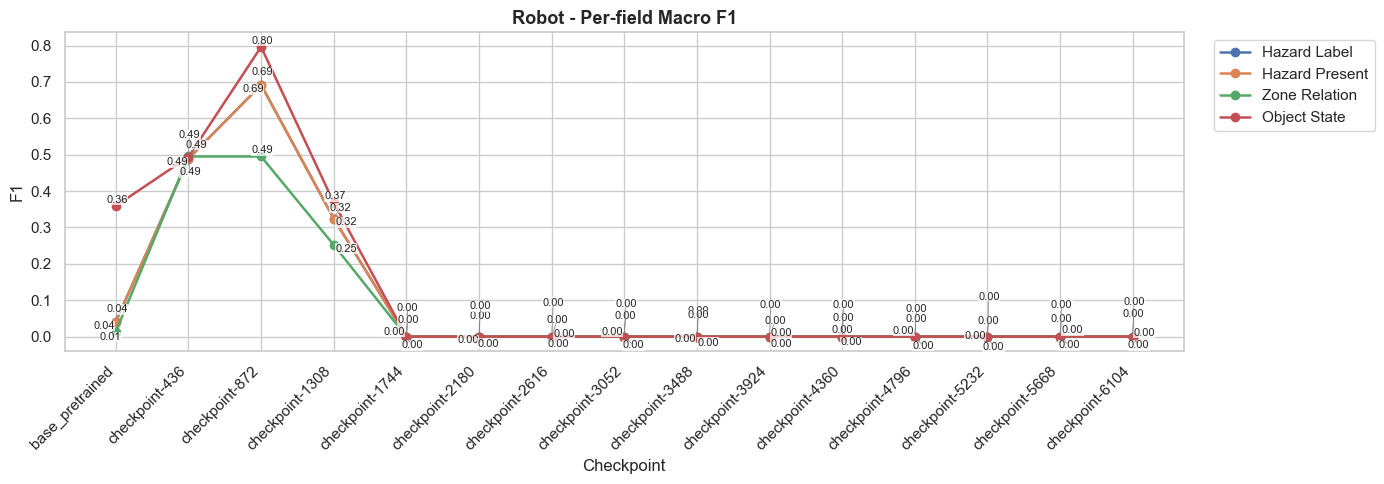

0 [-0.6279382  -0.22455147]
15 [ 0.43019304 -0.01307577]
1 [ 0.44885316 -0.20041929]
16 [-0.9381149  -0.18873669]
2 [-0.68208868 -0.34883105]
17 [0.59980005 0.42141604]
3 [-0.15401009  0.98583702]
18 [0.50429208 0.33206856]
4 [0.34781157 0.18879579]
19 [-0.90456543 -0.88305745]
34 [ 0.90071876 -0.11373913]
49 [-0.63495713 -0.69048759]
5 [0.26118848 0.4313912 ]
20 [ 0.21706428 -0.25102078]
35 [-0.93789505  0.36279827]
50 [0.53804891 0.92675303]
6 [-0.12494793 -0.50113403]
21 [-0.10695231  0.11534541]
36 [ 0.96013316 -0.2433652 ]
51 [0.65340644 0.96546732]
7 [-0.32956913  0.40309342]
22 [ 0.26557672 -0.81068464]
37 [ 0.93947362 -0.92703862]
52 [ 0.88864852 -0.64671928]
8 [-0.46785296  0.63658181]
23 [-0.08184449  0.07728155]
38 [0.28294819 0.0830547 ]
53 [-0.28190265 -0.13897633]
9 [-0.13231646 -0.28863502]
24 [-0.63544832  0.14047748]
39 [ 0.39034517 -0.58042236]
54 [-0.55914733 -0.44071203]
10 [ 0.43530833 -0.6133365 ]
25 [0.37856312 0.56563217]
40 [0.33793213 0.54962777]
55 [0.7127086

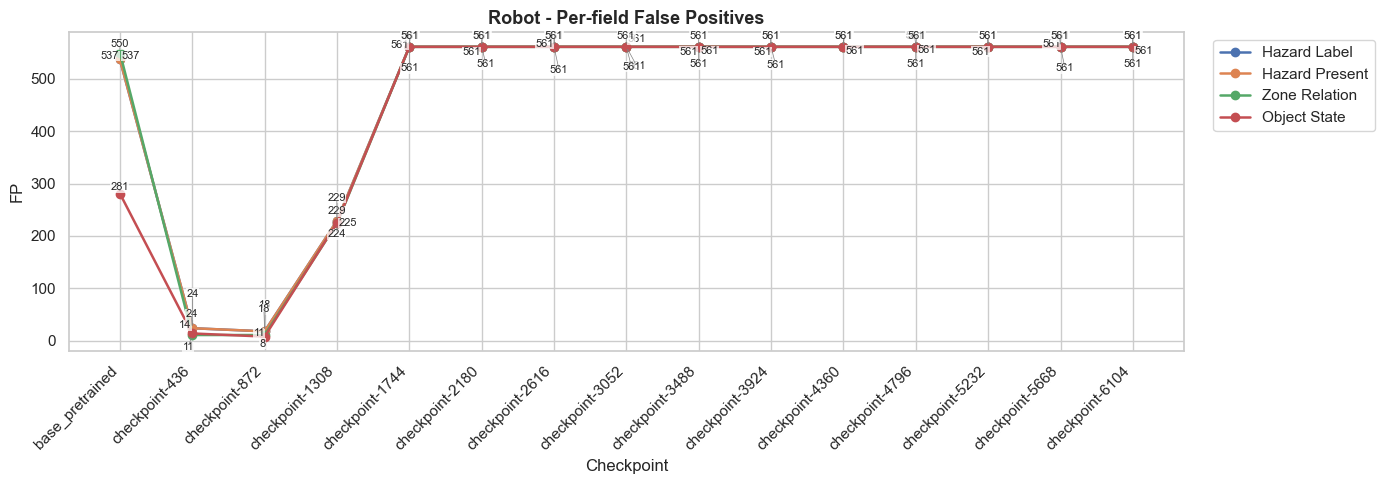

In [26]:
# ============================================
# Cell 6: Per-field ACC / F1 / FP for each set
# ============================================
plot_metric_family(summary_df, "combined", "acc", "Combined - Per-field Accuracy")
plot_metric_family(summary_df, "combined", "f1",  "Combined - Per-field Macro F1")
plot_metric_family(summary_df, "combined", "fp",  "Combined - Per-field False Positives")

plot_metric_family(summary_df, "forklift", "acc", "Forklift - Per-field Accuracy")
plot_metric_family(summary_df, "forklift", "f1",  "Forklift - Per-field Macro F1")
plot_metric_family(summary_df, "forklift", "fp",  "Forklift - Per-field False Positives")

plot_metric_family(summary_df, "robot", "acc", "Robot - Per-field Accuracy")
plot_metric_family(summary_df, "robot", "f1",  "Robot - Per-field Macro F1")
plot_metric_family(summary_df, "robot", "fp",  "Robot - Per-field False Positives")

In [27]:
# ===================================================
# Cell 7: Load per-sample rows from all result files
# ===================================================
sample_rows = []

for file_path in json_files:
    filename = os.path.basename(file_path)
    checkpoint = filename.replace(".json", "")
    step = parse_step(filename)

    with open(file_path, "r", encoding="utf-8") as f:
        content = json.load(f)

    per_sample = content.get("per_sample", [])
    for s in per_sample:
        gt = s.get("ground_truth") or {}
        pred = s.get("prediction_parsed") or {}
        meta = s.get("meta") or {}
        field_matches = s.get("field_matches") or {}

        row = {
            "checkpoint": checkpoint,
            "step": step,
            "sample_id": s.get("sample_id"),
            "task": s.get("task"),
            "exact_match": s.get("exact_match"),
            "ground_truth_parse_failed": s.get("ground_truth_parse_failed"),
            "inference_time_sec": s.get("inference_time_sec"),
            "hard_negative_bucket": s.get("hard_negative_bucket"),
            "prediction_raw": s.get("prediction_raw"),
            "ground_truth_text": s.get("ground_truth_text"),
            "source_video_id": meta.get("source_video_id"),
            "clip_start_sec": meta.get("clip_start_sec"),
            "clip_end_sec": meta.get("clip_end_sec"),
            "anchor_start_sec": meta.get("anchor_start_sec"),
            "anchor_end_sec": meta.get("anchor_end_sec"),
            "is_transition": meta.get("is_transition"),
            "is_ambiguous": meta.get("is_ambiguous"),
        }

        for field in ALL_FIELDS:
            row[f"gt_{field}"] = gt.get(field)
            row[f"pred_{field}"] = pred.get(field)
            row[f"match_{field}"] = field_matches.get(field)

        # True hazard false positive: GT says no, prediction says yes
        row["hazard_fp"] = (gt.get("hazard_present") == "no") and (pred.get("hazard_present") == "yes")

        # True hazard false negative: GT says yes, prediction says no
        row["hazard_fn"] = (gt.get("hazard_present") == "yes") and (pred.get("hazard_present") == "no")

        # Useful backup view: negative samples with any mistake
        row["negative_case_error"] = (gt.get("hazard_present") == "no") and (s.get("exact_match") is False)

        sample_rows.append(row)

samples_df = pd.DataFrame(sample_rows).sort_values(["step", "task", "sample_id"]).reset_index(drop=True)
samples_df.head()

,checkpoint,step,sample_id,task,exact_match,ground_truth_parse_failed,inference_time_sec,hard_negative_bucket,prediction_raw,ground_truth_text,...,match_zone_relation,gt_object_state,pred_object_state,match_object_state,gt_object_direction,pred_object_direction,match_object_direction,hazard_fp,hazard_fn,negative_case_error
0,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.3619,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True
1,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.1667,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True
2,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.3685,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True
3,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.2085,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True
4,base_pretrained,0,fork_금진Camera05_S20251213073941_E2025121307474...,forklift,False,False,6.1923,inside_stationary,"```json\n{\n ""hazard_label"": ""no_hazard"",\n ...","{""hazard_label"": ""no_hazard"", ""hazard_present""...",...,False,stationary,moving,False,none,towards,False,False,False,True


In [28]:
# ===========================================
# Cell 8: Count hazard FPs and FNs by run/task
# ===========================================
fp_fn_summary = (
    samples_df
    .groupby(["checkpoint", "task"], as_index=False)
    .agg(
        hazard_fp_count=("hazard_fp", "sum"),
        hazard_fn_count=("hazard_fn", "sum"),
        negative_case_error_count=("negative_case_error", "sum"),
        total_samples=("sample_id", "count"),
    )
    .sort_values(["checkpoint", "task"])
)

display(fp_fn_summary)

,checkpoint,task,hazard_fp_count,hazard_fn_count,negative_case_error_count,total_samples
0,base_pretrained,forklift,0,27,83,200
1,base_pretrained,robot,0,537,20,561
2,checkpoint-1308,forklift,0,3,105,200
3,checkpoint-1308,robot,10,0,21,561
4,checkpoint-1744,forklift,0,0,173,200
5,checkpoint-1744,robot,0,0,24,561
6,checkpoint-2180,forklift,0,0,173,200
7,checkpoint-2180,robot,0,0,24,561
8,checkpoint-2616,forklift,0,0,173,200
9,checkpoint-2616,robot,0,0,24,561


0 [-0.93739007  0.42788584]
15 [0.86311475 0.09713004]
2 [-0.68721547 -0.90852891]
17 [ 0.45952426 -0.94002172]
3 [ 0.05680434 -0.2172127 ]
18 [0.91504181 0.35441637]
4 [ 0.32340799 -0.13072813]
19 [0.10150166 0.32191964]
5 [-0.58286852 -0.66844062]
20 [-0.66874202  0.11891356]
6 [ 0.79587416 -0.84959784]
21 [ 0.89039995 -0.0884857 ]
7 [ 0.78051298 -0.44509021]
22 [-0.67155909 -0.81165949]
9 [-0.95063067  0.22061912]
24 [0.81675619 0.41899562]
10 [-0.5059603   0.21366094]
25 [0.79467441 0.88075061]
11 [-0.52106403  0.88713089]
26 [ 0.81633387 -0.57668655]
12 [-0.51094079  0.64541387]
27 [ 0.91728742 -0.02254472]
13 [0.18364559 0.19305819]
28 [ 0.15183023 -0.62919024]


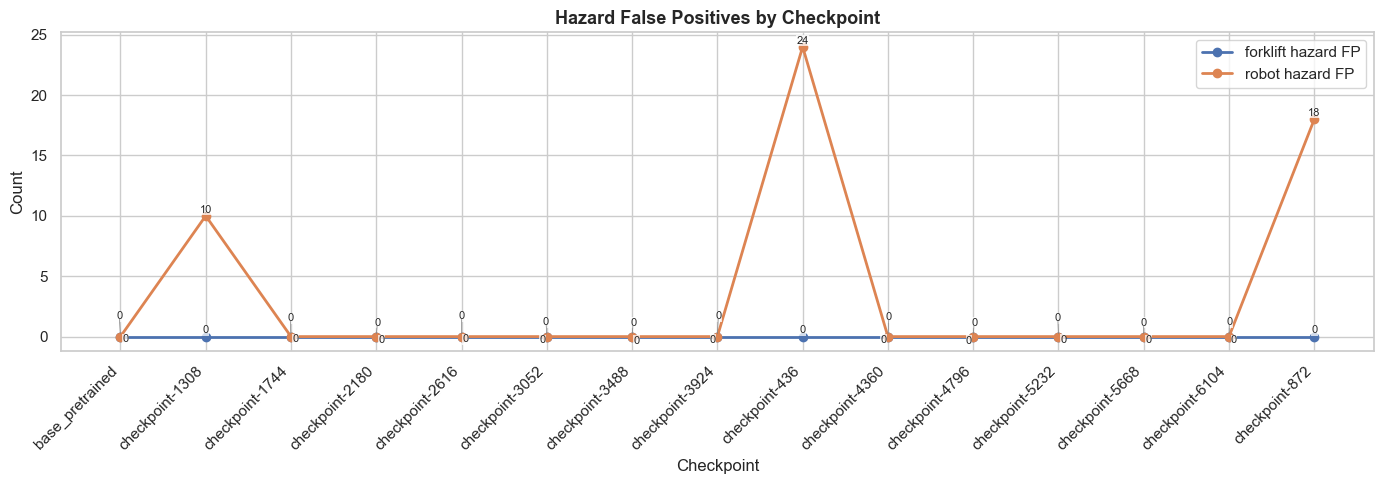

In [29]:
plt.figure(figsize=(14, 5))
texts = []

for task_name, sub_df in fp_fn_summary.groupby("task"):
    plt.plot(
        sub_df["checkpoint"],
        sub_df["hazard_fp_count"],
        marker="o",
        linewidth=2,
        label=f"{task_name} hazard FP"
    )
    annotate_series(sub_df["checkpoint"], sub_df["hazard_fp_count"], texts, fmt="{:.0f}")

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
    only_move={"points": "y", "text": "y"},
    force_text=0.8,
    force_points=0.3
)

plt.title("Hazard False Positives by Checkpoint", fontsize=13, fontweight="bold")
plt.xlabel("Checkpoint")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# Cell 8A: Ground-truth sample counts per label / per field
# ============================================================
count_rows = []

for _, row in samples_df.iterrows():
    task = row["task"]
    checkpoint = row["checkpoint"]

    for field in ALL_FIELDS:
        gt_col = f"gt_{field}"
        value = row.get(gt_col, None)

        # Skip robot object_direction since it is not a task field there
        if pd.isna(value) or value is None:
            continue

        count_rows.append({
            "checkpoint": checkpoint,
            "task": task,
            "field": field,
            "label": value,
            "count_type": "ground_truth"
        })

label_counts_df = (
    pd.DataFrame(count_rows)
    .groupby(["checkpoint", "task", "field", "label", "count_type"], as_index=False)
    .size()
    .rename(columns={"size": "num_samples"})
    .sort_values(["checkpoint", "task", "field", "label"])
)

display(label_counts_df.head(50))

,checkpoint,task,field,label,count_type,num_samples
0,base_pretrained,forklift,hazard_label,no_hazard,ground_truth,173
1,base_pretrained,forklift,hazard_label,unsafe_forklift_approach,ground_truth,27
2,base_pretrained,forklift,hazard_present,no,ground_truth,173
3,base_pretrained,forklift,hazard_present,yes,ground_truth,27
4,base_pretrained,forklift,object_direction,away,ground_truth,23
5,base_pretrained,forklift,object_direction,none,ground_truth,147
6,base_pretrained,forklift,object_direction,towards,ground_truth,30
7,base_pretrained,forklift,object_state,moving,ground_truth,53
8,base_pretrained,forklift,object_state,no_forklift,ground_truth,130
9,base_pretrained,forklift,object_state,stationary,ground_truth,17


In [31]:
# ============================================================
# Cell 8B: Prediction sample counts per label / per field
# ============================================================
pred_count_rows = []

for _, row in samples_df.iterrows():
    task = row["task"]
    checkpoint = row["checkpoint"]

    for field in ALL_FIELDS:
        pred_col = f"pred_{field}"
        value = row.get(pred_col, None)

        if pd.isna(value) or value is None:
            continue

        pred_count_rows.append({
            "checkpoint": checkpoint,
            "task": task,
            "field": field,
            "label": value,
            "count_type": "prediction"
        })

pred_label_counts_df = (
    pd.DataFrame(pred_count_rows)
    .groupby(["checkpoint", "task", "field", "label", "count_type"], as_index=False)
    .size()
    .rename(columns={"size": "num_samples"})
    .sort_values(["checkpoint", "task", "field", "label"])
)

# display(pred_label_counts_df.head(50))

In [32]:
# ============================================================
# Cell 8D: Easy pivot view
# ============================================================
selected_checkpoint = summary_df.iloc[-1]["checkpoint"]

label_counts_pivot = (
    all_label_counts_df[all_label_counts_df["checkpoint"] == selected_checkpoint]
    .pivot_table(
        index=["task", "field", "label"],
        columns="count_type",
        values="num_samples",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
    .sort_values(["task", "field", "label"])
)

print(f"Checkpoint: {selected_checkpoint}")
display(label_counts_pivot)

Checkpoint: checkpoint-6104


count_type,task,field,label


In [33]:
# =======================================================
# Cell 10: Sample view for actual hazard false positives
# =======================================================
# Change this if you want a specific checkpoint
selected_checkpoint = summary_df.iloc[-1]["checkpoint"]

fp_cases = (
    samples_df[
        (samples_df["checkpoint"] == selected_checkpoint) &
        (samples_df["hazard_fp"])
    ][[
        "checkpoint", "task", "sample_id", "source_video_id",
        "clip_start_sec", "clip_end_sec",
        "gt_hazard_label", "pred_hazard_label",
        "gt_hazard_present", "pred_hazard_present",
        "gt_zone_relation", "pred_zone_relation",
        "gt_object_state", "pred_object_state",
        "gt_object_direction", "pred_object_direction",
        "hard_negative_bucket", "prediction_raw"
    ]]
    .sort_values(["task", "sample_id"])
)

print(f"Selected checkpoint: {selected_checkpoint}")
print(f"Number of hazard false positives: {len(fp_cases)}")
display(fp_cases.head(20))

Selected checkpoint: checkpoint-6104
Number of hazard false positives: 0


,checkpoint,task,sample_id,source_video_id,clip_start_sec,clip_end_sec,gt_hazard_label,pred_hazard_label,gt_hazard_present,pred_hazard_present,gt_zone_relation,pred_zone_relation,gt_object_state,pred_object_state,gt_object_direction,pred_object_direction,hard_negative_bucket,prediction_raw


In [34]:
# ====================================================================
# Cell 11: Backup sample view if hazard FP count is zero for a run
# ====================================================================
# This is useful for runs like "always predicts no hazard",
# where there may be zero hazard FPs but still many wrong negative cases.

negative_errors = (
    samples_df[
        (samples_df["checkpoint"] == selected_checkpoint) &
        (samples_df["negative_case_error"])
    ][[
        "checkpoint", "task", "sample_id", "source_video_id",
        "clip_start_sec", "clip_end_sec",
        "gt_hazard_label", "pred_hazard_label",
        "gt_hazard_present", "pred_hazard_present",
        "gt_zone_relation", "pred_zone_relation",
        "gt_object_state", "pred_object_state",
        "gt_object_direction", "pred_object_direction",
        "hard_negative_bucket", "prediction_raw"
    ]]
    .sort_values(["task", "sample_id"])
)

print(f"Selected checkpoint: {selected_checkpoint}")
print(f"Negative samples with any mistake: {len(negative_errors)}")
display(negative_errors.head(20))

Selected checkpoint: checkpoint-6104
Negative samples with any mistake: 197


,checkpoint,task,sample_id,source_video_id,clip_start_sec,clip_end_sec,gt_hazard_label,pred_hazard_label,gt_hazard_present,pred_hazard_present,gt_zone_relation,pred_zone_relation,gt_object_state,pred_object_state,gt_object_direction,pred_object_direction,hard_negative_bucket,prediction_raw
10654,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,28.0,33.0,no_hazard,None,no,None,inside,None,stationary,None,none,None,inside_stationary,
10655,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,41.0,46.0,no_hazard,None,no,None,inside,None,stationary,None,none,None,inside_stationary,
10656,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,51.0,56.0,no_hazard,None,no,None,inside,None,stationary,None,none,None,inside_stationary,
10657,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,52.0,57.0,no_hazard,None,no,None,inside,None,stationary,None,none,None,inside_stationary,
10658,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,57.0,62.0,no_hazard,None,no,None,inside,None,stationary,None,none,None,inside_stationary,
10659,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,59.0,64.0,no_hazard,None,no,None,inside,None,stationary,None,none,None,inside_stationary,
10660,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,75.0,80.0,no_hazard,None,no,None,no_forklift,None,no_forklift,None,none,None,no_forklift,
10661,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,75.0,80.0,no_hazard,None,no,None,no_forklift,None,no_forklift,None,none,None,no_forklift,
10665,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,102.0,107.0,no_hazard,None,no,None,no_forklift,None,no_forklift,None,none,None,no_forklift,
10666,checkpoint-6104,forklift,fork_금진Camera05_S20251213073941_E2025121307474...,fork_금진Camera05_S20251213073941_E20251213074740,102.0,107.0,no_hazard,None,no,None,no_forklift,None,no_forklift,None,none,None,no_forklift,


In [35]:
# =========================================================
# Cell 12: Optional - inspect one specific sample in detail
# =========================================================
sample_to_inspect = None  # e.g. "fork_금진Camera05_S20251213073941_E20251213074740__000087000_000092000"

if sample_to_inspect:
    display(
        samples_df[samples_df["sample_id"] == sample_to_inspect].T
    )